# 01 - Deep Q-Learning su CartPole

Questo notebook valida l'implementazione di **Deep Q-Learning (DQN)** su `CartPole-v1`.

A differenza degli algoritmi di Policy Gradient (*REINFORCE* e *A2C*), DQN è un metodo **off-policy value-based** che approssima direttamente la funzione valore azione-stato $Q^*(s, a)$ mediante una rete neurale multi-strato (`QNetwork`).

Per stabilizzare l'addestramento e rompere le forti correlazioni temporali presenti nelle traiettorie sequenziali, l'implementazione integra:
1. **Replay Buffer**: memoria FIFO da cui estrarre minibatch casuali di transizioni $(s_t, a_t, r_t, s_{t+1}, d_t)$.
2. **Target Network**: copia lenta dei pesi della rete principale usata per calcolare il target temporale TD senza instabilità da feedback positivo:
   $$Y_t = R_t + \gamma (1 - d_t) \max_{a'} Q_{\text{target}}(S_{t+1}, a' ; \theta^-)$$
3. **Esplorazione Epsilon-Greedy**: bilanciamento tra esplorazione e sfruttamento con decadimento lineare della probabilità $\epsilon$.

## Setup

In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from torch.optim import Adam

current_path = Path.cwd().resolve()
project_root = current_path
for candidate in [current_path, *current_path.parents]:
    if (candidate / "DLA_LAB3").exists():
        project_root = candidate
        break

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.dqn import evaluate_q_policy, render_q_policy, train_dqn, train_vectorized_dqn
from DLA_LAB3.src.networks import QNetwork
from DLA_LAB3.src.plotting import plot_seed_eval_curves
from DLA_LAB3.src.utils import get_device, make_vector_env, restore_model_state, seed_environment, set_seed

In [2]:
config_path = project_root / "DLA_LAB3" / "exercise_3_2_dql" / "config_cartpole.yaml"
with config_path.open("r", encoding="utf-8") as file:
    raw_config = yaml.safe_load(file)

CONFIG = {
    "environment_name": raw_config["environment"]["name"],
    "max_steps": raw_config["environment"]["max_steps"],
    "seeds": raw_config["training"]["seeds"],
    "num_episodes": raw_config["training"]["num_episodes"],
    "gamma": raw_config["training"]["gamma"],
    "learning_rate": raw_config["training"]["learning_rate"],
    "hidden_dim": raw_config["training"]["hidden_dim"],
    "batch_size": raw_config["training"]["batch_size"],
    "replay_capacity": raw_config["training"]["replay_capacity"],
    "min_replay_size": raw_config["training"]["min_replay_size"],
    "train_every_steps": raw_config["training"]["train_every_steps"],
    "gradient_steps": raw_config["training"].get("gradient_steps", 1),
    "vectorized": raw_config["training"].get("vectorized", False),
    "num_envs": raw_config["training"].get("num_envs", 1),
    "vector_env_type": raw_config["training"].get("vector_env_type", "sync"),
    "target_update_every_steps": raw_config["training"]["target_update_every_steps"],
    "epsilon_start": raw_config["training"]["epsilon_start"],
    "epsilon_end": raw_config["training"]["epsilon_end"],
    "epsilon_decay_steps": raw_config["training"]["epsilon_decay_steps"],
    "gradient_clip": raw_config["training"]["gradient_clip"],
    "evaluation_episodes": raw_config["evaluation"]["num_episodes"],
    "eval_every_n": raw_config["evaluation"]["eval_every_n"],
    "eval_episodes_m": raw_config["evaluation"]["eval_episodes_m"],
}

set_seed(CONFIG["seeds"][0])
device = get_device(force_cpu=raw_config["training"]["force_cpu"])
device

device(type='cpu')

## Ambiente CartPole

In [3]:
env = gym.make(CONFIG["environment_name"])
observation, _ = seed_environment(env, CONFIG["seeds"][0])

observation_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("Observation iniziale:", observation)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation dim:", observation_dim)
print("Action dim:", action_dim)

Observation iniziale: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Observation dim: 4
Action dim: 2


## Training per seed

Addestriamo una Q-network indipendente per ciascuno dei seed configurati, garantendo una valutazione statistica robusta della convergenza.

Durante l'addestramento, ogni $N$ episodi la policy deterministica indotta dal $\arg\max_a Q(s, a)$ viene valutata senza esplorazione ($\epsilon = 0$). Il checkpoint che ottiene il reward di valutazione più elevato viene salvato in memoria e ripristinato al termine del training per la valutazione finale.

In [4]:
# Conserviamo una Q-network finale per seed insieme alle relative metriche.
training_results = {}
trained_networks = {}
final_rows = []

for seed in CONFIG["seeds"]:
    print(f"Run seed {seed}")
    set_seed(seed)

    # Gli ambienti paralleli alimentano lo stesso replay buffer condiviso.
    use_vectorized_training = CONFIG["vectorized"] and CONFIG["num_envs"] > 1
    if use_vectorized_training:
        train_env = make_vector_env(
            environment_name=CONFIG["environment_name"],
            seed=seed,
            num_envs=CONFIG["num_envs"],
            vector_env_type=CONFIG["vector_env_type"],
        )
    else:
        train_env = gym.make(CONFIG["environment_name"])
        seed_environment(train_env, seed)

    eval_env_inter = gym.make(CONFIG["environment_name"])
    seed_environment(eval_env_inter, seed + 10_000)

    q_network = QNetwork(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=CONFIG["hidden_dim"],
    ).to(device)
    target_network = QNetwork(
        observation_dim=observation_dim,
        action_dim=action_dim,
        hidden_dim=CONFIG["hidden_dim"],
    ).to(device)
    optimizer = Adam(q_network.parameters(), lr=CONFIG["learning_rate"])

    if use_vectorized_training:
        training_result = train_vectorized_dqn(
            envs=train_env,
            q_network=q_network,
            target_network=target_network,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            batch_size=CONFIG["batch_size"],
            replay_capacity=CONFIG["replay_capacity"],
            min_replay_size=CONFIG["min_replay_size"],
            train_every_steps=CONFIG["train_every_steps"],
            gradient_steps=CONFIG["gradient_steps"],
            target_update_every_steps=CONFIG["target_update_every_steps"],
            epsilon_start=CONFIG["epsilon_start"],
            epsilon_end=CONFIG["epsilon_end"],
            epsilon_decay_steps=CONFIG["epsilon_decay_steps"],
            gradient_clip=CONFIG["gradient_clip"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    else:
        training_result = train_dqn(
            env=train_env,
            q_network=q_network,
            target_network=target_network,
            optimizer=optimizer,
            device=device,
            num_episodes=CONFIG["num_episodes"],
            gamma=CONFIG["gamma"],
            max_steps=CONFIG["max_steps"],
            batch_size=CONFIG["batch_size"],
            replay_capacity=CONFIG["replay_capacity"],
            min_replay_size=CONFIG["min_replay_size"],
            train_every_steps=CONFIG["train_every_steps"],
            target_update_every_steps=CONFIG["target_update_every_steps"],
            epsilon_start=CONFIG["epsilon_start"],
            epsilon_end=CONFIG["epsilon_end"],
            epsilon_decay_steps=CONFIG["epsilon_decay_steps"],
            gradient_clip=CONFIG["gradient_clip"],
            eval_env=eval_env_inter,
            eval_every_n=CONFIG["eval_every_n"],
            eval_episodes_m=CONFIG["eval_episodes_m"],
        )
    train_env.close()
    eval_env_inter.close()

    # Ripristiniamo il checkpoint scelto sulla valutazione periodica, non l'ultimo update.
    restore_model_state(q_network, training_result.best_q_state)
    restore_model_state(target_network, training_result.best_target_state)

    # Un seed distinto separa la valutazione finale da training e selezione del checkpoint.
    final_eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(final_eval_env, seed + 20_000)
    final_eval = evaluate_q_policy(
        env=final_eval_env,
        q_network=q_network,
        device=device,
        num_episodes=CONFIG["evaluation_episodes"],
        max_steps=CONFIG["max_steps"],
    )
    final_eval_env.close()

    training_results[seed] = training_result
    trained_networks[seed] = q_network
    row = {
        "Seed": seed,
        "Final Train Reward": round(training_result.episode_rewards[-1], 1),
        "Best Train Reward": round(max(training_result.episode_rewards), 1),
        "Eval Mean Reward": round(final_eval["mean_reward"], 1),
        "Eval Min Reward": round(final_eval["min_reward"], 1),
        "Eval Max Reward": round(final_eval["max_reward"], 1),
        "Eval Mean Length": round(final_eval["mean_length"], 1),
        "Best Checkpoint Episode": training_result.best_eval_episode,
        "Best Checkpoint Reward": round(training_result.best_eval_mean_reward, 1),
    }
    final_rows.append(row)
    print(row)

results_table = pd.DataFrame(final_rows)
display(results_table)

best_seed = int(results_table.sort_values("Eval Mean Reward", ascending=False).iloc[0]["Seed"])
print(f"Seed migliore in valutazione: {best_seed}")

Run seed 42
{'Seed': 42, 'Final Train Reward': 95.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 800, 'Best Checkpoint Reward': 500.0}
Run seed 123
{'Seed': 123, 'Final Train Reward': 500.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 820, 'Best Checkpoint Reward': 500.0}
Run seed 314
{'Seed': 314, 'Final Train Reward': 500.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 400, 'Best Checkpoint Reward': 500.0}
Run seed 2024
{'Seed': 2024, 'Final Train Reward': 176.0, 'Best Train Reward': 500.0, 'Eval Mean Reward': 500.0, 'Eval Min Reward': 500.0, 'Eval Max Reward': 500.0, 'Eval Mean Length': 500.0, 'Best Checkpoint Episode': 520, 'Best Checkpoi

,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,42,95.0,500.0,500.0,500.0,500.0,500.0,800,500.0
1,123,500.0,500.0,500.0,500.0,500.0,500.0,820,500.0
2,314,500.0,500.0,500.0,500.0,500.0,500.0,400,500.0
3,2024,176.0,500.0,500.0,500.0,500.0,500.0,520,500.0
4,9001,15.0,500.0,473.1,459.0,500.0,473.1,420,470.7


Seed migliore in valutazione: 42


## Curve di valutazione periodica

Il grafico mette a confronto l'andamento stocastico durante l'addestramento (reward influenzato da $\epsilon$-greedy) con la valutazione deterministica periodica.

Si osserva come la policy deterministica converga rapidamente verso il punteggio massimo di 500.0, evidenziando l'efficacia del bootstrap TD stabilizzato dalla Target Network.

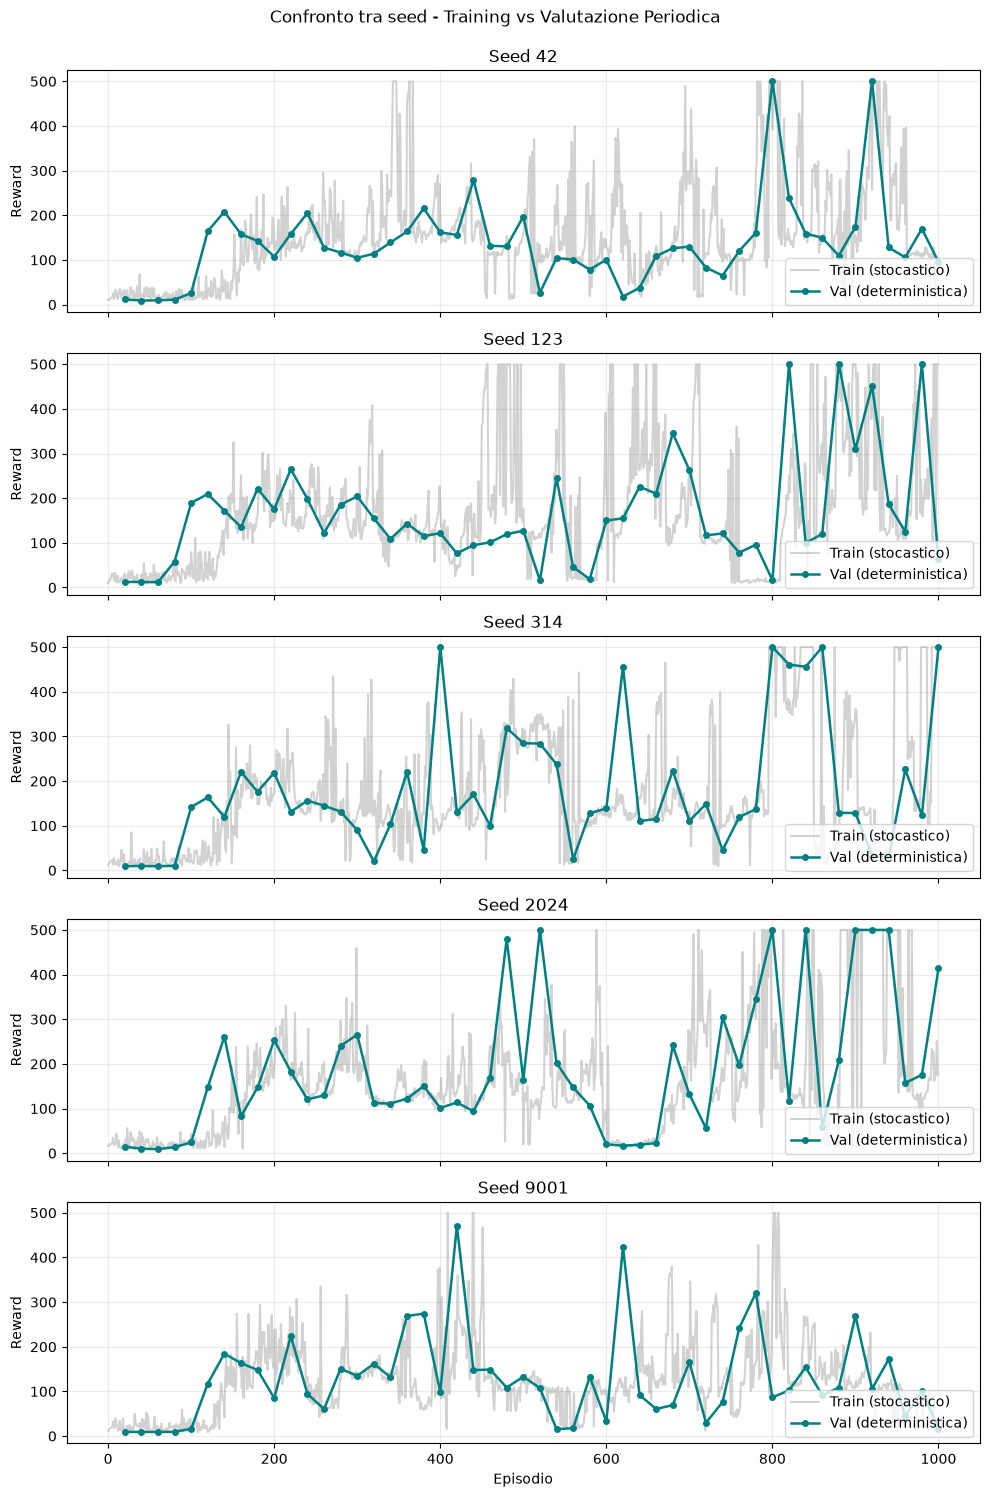

In [5]:
plot_seed_eval_curves(
    {
        seed: {
            "train_rewards": result.episode_rewards,
            "eval_intervals": result.eval_episodes or [],
            "eval_rewards": result.eval_mean_rewards or [],
        }
        for seed, result in training_results.items()
    }
)

## Analisi della Loss DQN

La loss di Deep Q-Learning misura l'errore quadratico/Huber tra le stime correnti $Q(s, a)$ e i target calcolati con la Target Network. Nelle figure sottostanti le curve sono mostrate separatamente per seed per apprezzare la dinamica di ottimizzazione sui singoli minibatch campionati dal Replay Buffer.

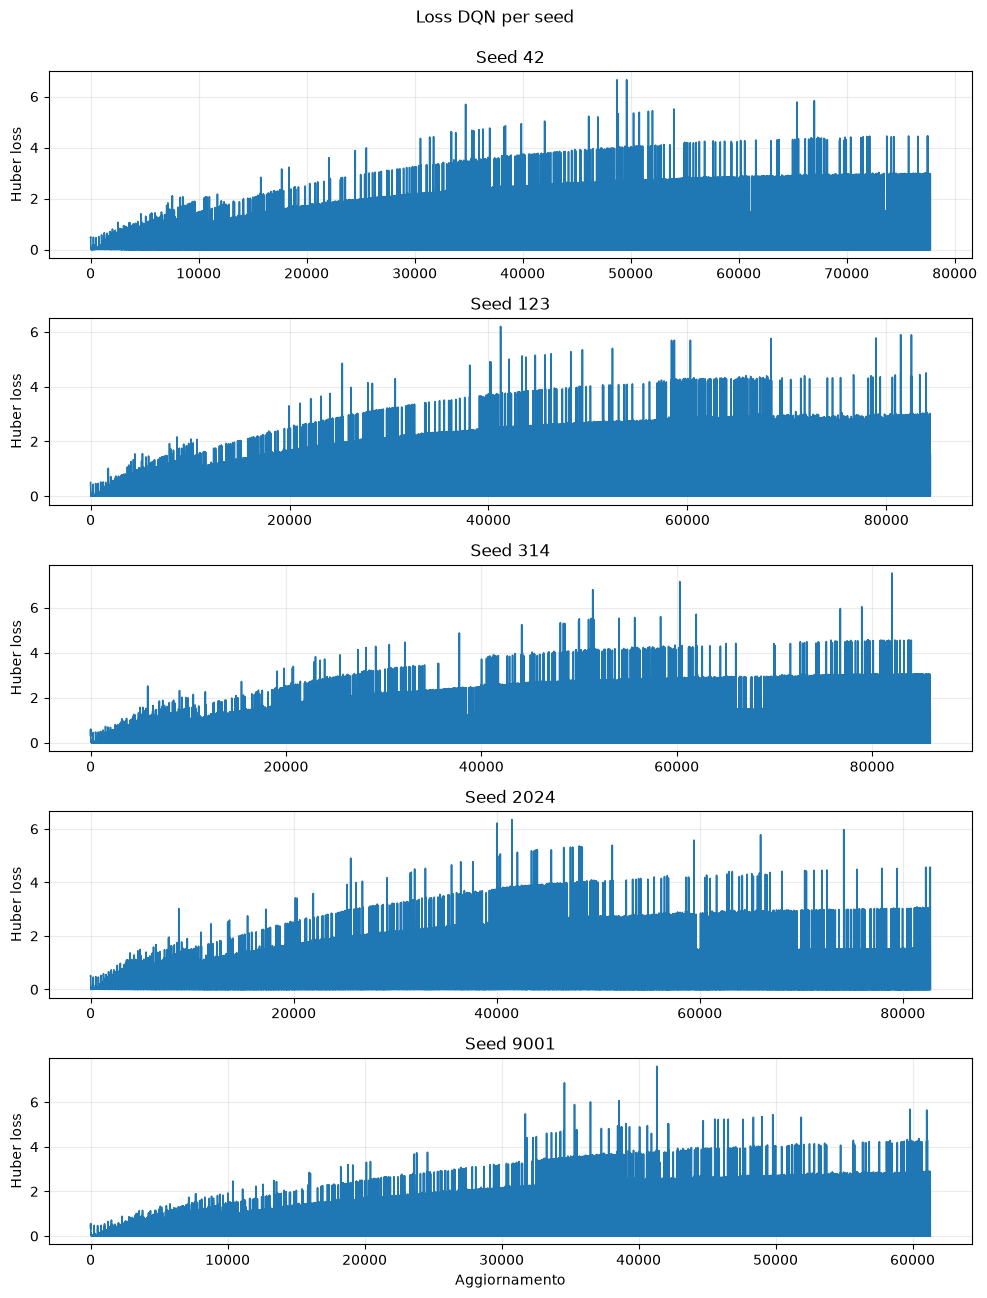

In [6]:
fig, axes = plt.subplots(
    len(training_results),
    1,
    figsize=(10, 2.6 * len(training_results)),
    sharex=False,
)

if len(training_results) == 1:
    axes = [axes]

for axis, (seed, result) in zip(axes, training_results.items()):
    axis.plot(result.losses, linewidth=1.2, color="tab:blue")
    axis.set_title(f"Seed {seed}")
    axis.set_ylabel("Huber loss")
    axis.grid(alpha=0.25)

axes[-1].set_xlabel("Aggiornamento")
fig.suptitle("Loss DQN per seed", y=0.995)
fig.tight_layout()
plt.show()

## Risultati aggregati e Discussione

La tabella sottostante riassume le metriche finali di valutazione deterministica per ciascun seed dopo il ripristino del miglior checkpoint, unitamente alle statistiche aggregate (media, deviazione standard, minimo e massimo).

Su `CartPole-v1`, quattro seed raggiungono il punteggio massimo di `500.0`, mentre il seed 9001 ottiene `473.1`. La media aggregata e' `494.6 ± 12.0`: DQN risulta quindi efficace e stabile, pur conservando una variabilita' misurabile tra le inizializzazioni.

In [7]:
aggregated_table = results_table[
    ["Eval Mean Reward", "Eval Min Reward", "Eval Max Reward", "Eval Mean Length"]
].agg(["mean", "std", "min", "max"])
display(aggregated_table)

,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length
mean,494.620000,491.800000,500.0,494.620000
std,12.030046,18.335757,0.0,12.030046
min,473.100000,459.000000,500.0,473.100000
max,500.000000,500.000000,500.0,500.000000


## Visualizzazione real time

Renderizzo la Q-policy del seed migliore secondo la valutazione finale.

In [8]:
render_rewards = render_q_policy(
    environment_name=CONFIG["environment_name"],
    q_network=trained_networks[best_seed],
    device=device,
    num_episodes=3,
    max_steps=CONFIG["max_steps"],
    frame_delay=0.02,
)
render_rewards

[500.0, 500.0, 500.0]

In [9]:
env.close()